In [6]:
# Threat Prediction using Logistic Regression
# This notebook trains a Logistic Regression classifier for detection of different types of attacks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, learning_curve
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_recall_fscore_support,
                            roc_curve, auc, roc_auc_score, log_loss)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')


In [7]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [9]:
# Load data
print("Loading data...")
data_df = pd.read_json(r'C:\Users\mps\Desktop\ML-Final\MLproj\waf\Preprocessing\complete_clean.json', orient='records')
print(f"\nDataset shape: {data_df.shape}")
print(f"\nFirst few rows:")
print(data_df.head())

# Display class distribution
print("\n=== Class Distribution ===")
counts = data_df['type'].value_counts()
print(counts)

Loading data...

Dataset shape: (90253, 2)

First few rows:
                                             pattern   type
0  /l_t@/_feu1wvhtpass2/1nieqnnrvnzktuasain/tg1ar...  valid
1  settotzeertnl='pn &8nafitm=74lukuc5t0j&4ttne=a...  valid
2                  /fonrnt/7n.d-4brssxb@tu/qghew.cfm  valid
3  dfdi7ftp=37redocumentiln&l4setbemmo=oe_rdzq&rt...  valid
4  /2m6vlb1r37jspc/cwvv/mbar/oqrd0/msc/etceebwgi/...  valid

=== Class Distribution ===
type
valid             60623
sqli              13153
xss                9730
cmdi               3461
path-traversal     3286
Name: count, dtype: int64


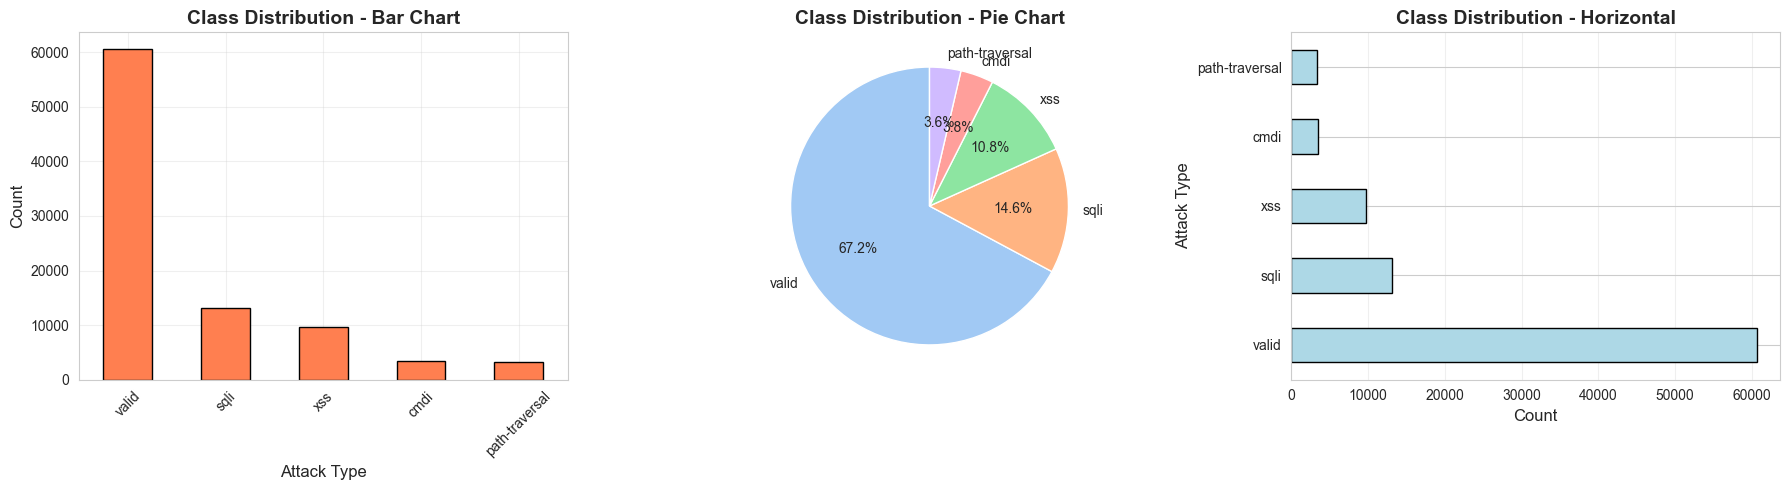

In [10]:
# Visualize class distribution with enhanced styling
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot
counts.plot(kind='bar', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('Class Distribution - Bar Chart', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attack Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Pie chart
counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90, 
            colors=sns.color_palette('pastel'))
axes[1].set_ylabel('')
axes[1].set_title('Class Distribution - Pie Chart', fontsize=14, fontweight='bold')

# Horizontal bar plot
counts.plot(kind='barh', ax=axes[2], color='lightblue', edgecolor='black')
axes[2].set_title('Class Distribution - Horizontal', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Count', fontsize=12)
axes[2].set_ylabel('Attack Type', fontsize=12)
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [11]:
# Load existing dataset splits
print("\n=== Loading Pre-split Data ===")
dataset = np.load('dataset.npz', allow_pickle=True)
trainX = dataset['trainX']
testX = dataset['testX']
trainY = dataset['trainY']
testY = dataset['testY']

# Convert to Python lists to reduce memory usage during cross-validation
# This prevents the numpy Unicode string array from consuming excessive memory
trainX = trainX.tolist()
testX = testX.tolist()
trainY = trainY.tolist()
testY = testY.tolist()

print(f"Training samples: {len(trainX)}")
print(f"Testing samples: {len(testX)}")
print(f"Total samples: {len(trainX) + len(testX)}")
print(f"\nUsing the same train-test split as the original SVM model for fair comparison.")
print("Note: Converted to lists to optimize memory usage during training.")




=== Loading Pre-split Data ===
Training samples: 67689
Testing samples: 22564
Total samples: 90253

Using the same train-test split as the original SVM model for fair comparison.
Note: Converted to lists to optimize memory usage during training.


In [12]:
# Create pipeline and perform grid search
print("\n=== Training Logistic Regression Model ===")
print("This may take a while...")

pipe = make_pipeline(
    TfidfVectorizer(input='content', lowercase=True, analyzer='char', max_features=1024),
    LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)
)

param_grid = {
    'tfidfvectorizer__ngram_range': [(1, 1), (1, 2), (1, 4)],
    'logisticregression__C': [0.1, 1, 10, 100],
    'logisticregression__penalty': ['l2'],
    'logisticregression__solver': ['lbfgs', 'saga']
}

grid = GridSearchCV(pipe, param_grid, cv=3, verbose=2, n_jobs=-1, scoring='accuracy')
grid.fit(trainX, trainY)



=== Training Logistic Regression Model ===
This may take a while...
Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'logisticregression__C': [0.1, 1, ...], 'logisticregression__penalty': ['l2'], 'logisticregression__solver': ['lbfgs', 'saga'], 'tfidfvectorizer__ngram_range': [(1, ...), (1, ...), ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [13]:
print(f"\n=== Best Parameters ===")
print(grid.best_params_)
print(f"Best Cross-Validation Score: {grid.best_score_:.4f}")


=== Best Parameters ===
{'logisticregression__C': 100, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga', 'tfidfvectorizer__ngram_range': (1, 4)}
Best Cross-Validation Score: 0.9907



=== Model Performance ===
Training Accuracy: 0.9993
Test Accuracy: 0.9919
Difference (Overfitting Check): 0.0074
Log Loss: 0.0256

=== Classification Report ===
                precision    recall  f1-score   support

          cmdi       0.94      0.95      0.94       865
path-traversal       0.98      0.96      0.97       822
          sqli       0.99      0.99      0.99      3288
         valid       0.99      1.00      1.00     15156
           xss       1.00      1.00      1.00      2433

      accuracy                           0.99     22564
     macro avg       0.98      0.98      0.98     22564
  weighted avg       0.99      0.99      0.99     22564


=== Confusion Matrix ===
[[  822     4    12    27     0]
 [    7   790     0    25     0]
 [   15     0  3245    28     0]
 [   31     8    13 15100     4]
 [    1     2     1     5  2424]]


Text(0.5, 47.7222222222222, 'Predicted Label')

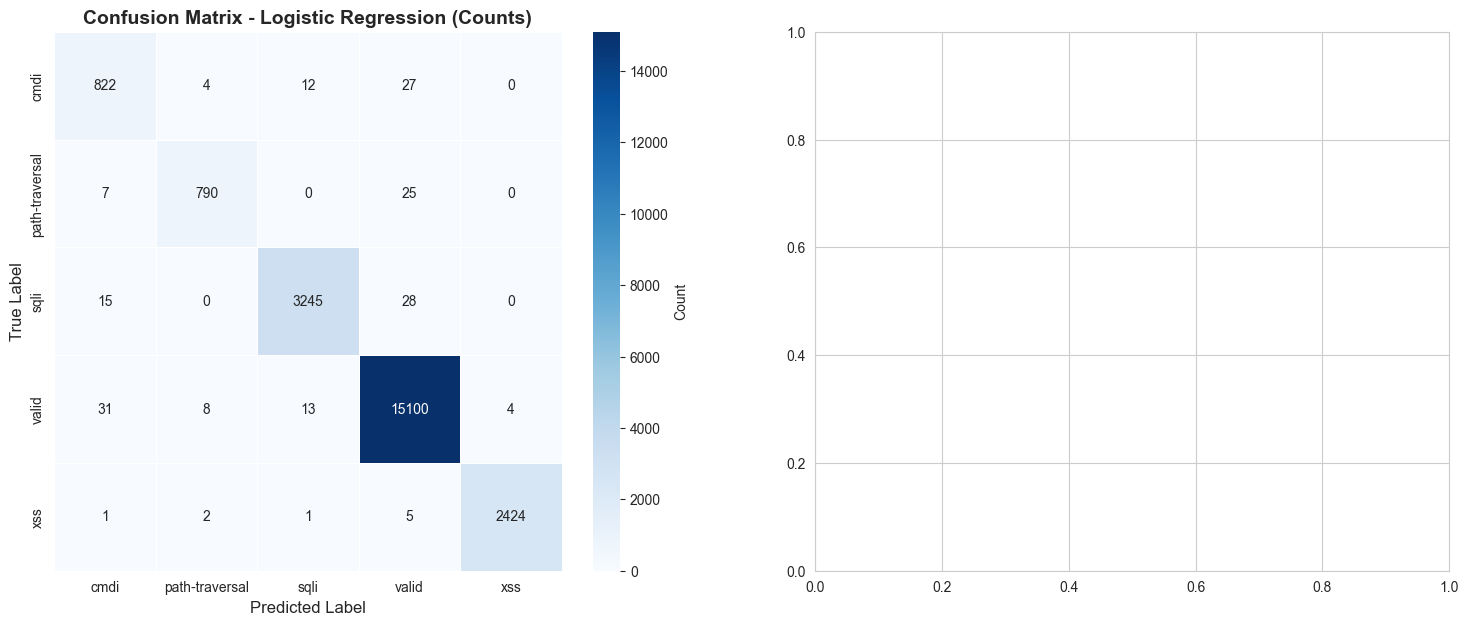

In [14]:
# Evaluate on test set
print(f"\n=== Model Performance ===")
test_score = grid.score(testX, testY)
train_score = grid.score(trainX, trainY)
print(f"Training Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")
print(f"Difference (Overfitting Check): {(train_score - test_score):.4f}")

# Get predictions
preds = grid.predict(testX)
proba = grid.predict_proba(testX)

# Calculate log loss
logloss = log_loss(testY, proba)
print(f"Log Loss: {logloss:.4f}")

# Detailed classification report
print(f"\n=== Classification Report ===")
report = classification_report(testY, preds, output_dict=True)
print(classification_report(testY, preds))

# Confusion Matrix
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(testY, preds)
print(cm)

# Plot enhanced confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

classes = sorted(data_df['type'].unique())

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'}, ax=ax1, linewidths=0.5)
ax1.set_title('Confusion Matrix - Logistic Regression (Counts)', 
              fontsize=14, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=12)
ax1.set_xlabel('Predicted Label', fontsize=12)

In [16]:
# Save the model
print("\n=== Saving Model ===")
import joblib
joblib.dump(grid, 'predictor_lr.joblib')
print("Model saved as 'predictor_lr.joblib'")

print("\n=== Training Complete ===")


=== Saving Model ===
Model saved as 'predictor_lr.joblib'

=== Training Complete ===
